In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [2]:
print("1. Loading the MNIST dataset...")

(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

print(f"  Total training samples : {X_train_full.shape[0]}")
print(f"  Test samples           : {X_test.shape[0]}")
print(f"  Image size             : {X_train_full.shape[1]}x{X_train_full.shape[2]} pixels")
print(f"  Pixel value range      : [{X_train_full.min()}, {X_train_full.max()}]")
print(f"  Number of classes      : {len(np.unique(y_train_full))}")

1. Loading the MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Total training samples : 60000
  Test samples           : 10000
  Image size             : 28x28 pixels
  Pixel value range      : [0, 255]
  Number of classes      : 10


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split( X_train_full, y_train_full, test_size=0.2, random_state=42)

In [4]:
print(f"  Training (train)      : {X_train.shape[0]}")
print(f"  Validation (val)      : {X_val.shape[0]}")
print(f"  Test                  : {X_test.shape[0]}")

  Training (train)      : 48000
  Validation (val)      : 12000
  Test                  : 10000


In [5]:
X_train_norm = X_train.astype("float32") / 255.0
X_val_norm   = X_val.astype("float32")   / 255.0
X_test_norm  = X_test.astype("float32")  / 255.0

print("[Min-Max Normalization] Pixel values were scaled from [0,255] to [0,1].")

[Min-Max Normalization] Pixel values were scaled from [0,255] to [0,1].


In [6]:
X_train_n = X_train_norm
X_val_n   = X_val_norm
X_test_n  = X_test_norm

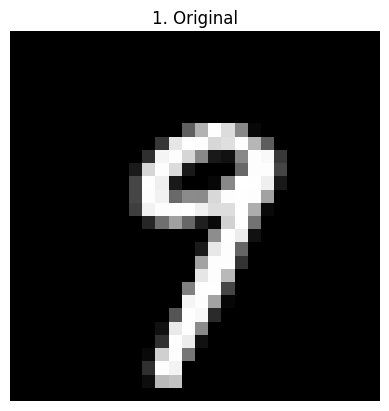

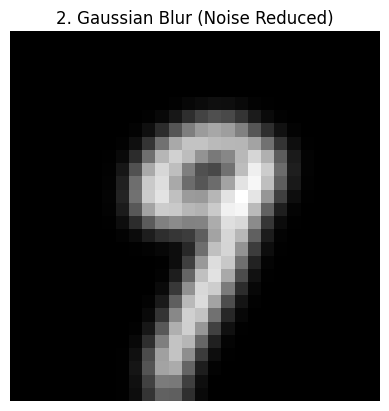

In [7]:
sample_img = X_train[50]

def show_image(image, title):
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

blurred = cv2.GaussianBlur(sample_img, (5, 5), 0)

show_image(sample_img, "1. Original")
show_image(blurred, "2. Gaussian Blur (Noise Reduced)")

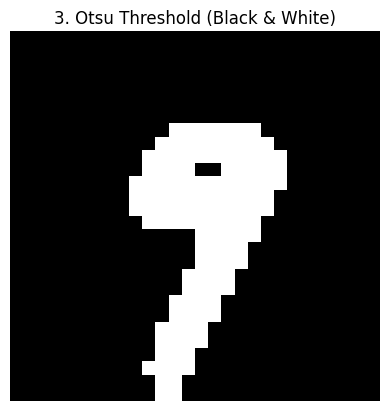

In [8]:
_, binary_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_image(binary_otsu, "3. Otsu Threshold (Black & White)")

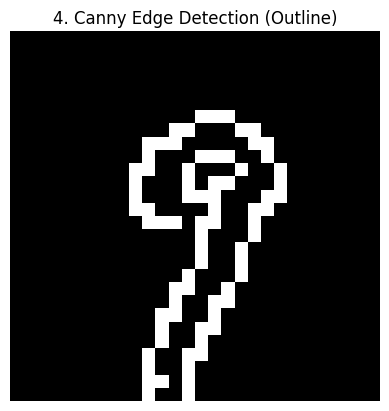

In [9]:
edges_canny = cv2.Canny(blurred, 50, 150)
show_image(edges_canny, "4. Canny Edge Detection (Outline)")

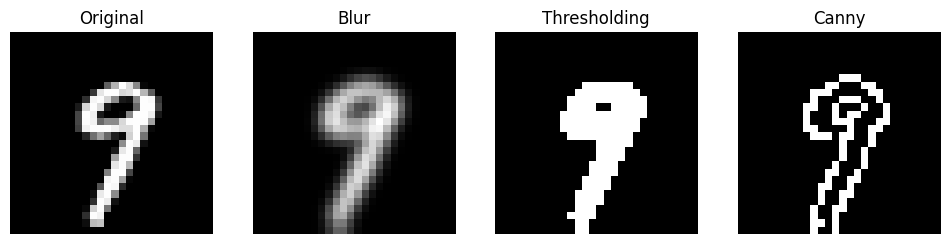

In [10]:
plt.figure(figsize=(12, 3))

processed_images = [sample_img, blurred, binary_otsu, edges_canny]
titles = ["Original", "Blur", "Thresholding", "Canny"]

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(processed_images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

In [11]:
X_train_cnn = np.expand_dims(X_train_n, axis=-1)
X_test_cnn  = np.expand_dims(X_test_n, axis=-1)

print(f"CNN Input Shape: {X_train_cnn.shape}")

X_train_32 = tf.image.resize(X_train_cnn, [32, 32]).numpy()
X_test_32  = tf.image.resize(X_test_cnn, [32, 32]).numpy()

print(f"New Shape: {X_train_32.shape}")

CNN Input Shape: (48000, 28, 28, 1)
New Shape: (48000, 32, 32, 1)


In [12]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, num_classes=10)
y_val_oh   = to_categorical(y_val,   num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

print(f"  Label example: {y_train[0]} → {y_train_oh[0]}")
print(f"  Shape: (N,) → (N, 10)  |  example: {y_train_oh.shape}")

  Label example: 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  Shape: (N,) → (N, 10)  |  example: (48000, 10)


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,
    fill_mode="nearest"
)

X_train = np.expand_dims(X_train, axis=-1)
datagen.fit(X_train)

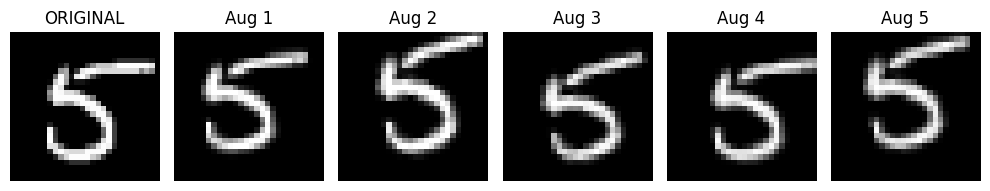

In [14]:
import matplotlib.pyplot as plt

img = X_train[0:1]
aug_iter = datagen.flow(img, batch_size=1)

plt.figure(figsize=(10, 2))

plt.subplot(1, 6, 1)
plt.imshow(img[0].squeeze(), cmap='gray')
plt.title("ORIGINAL")
plt.axis('off')

for i in range(2, 7):
    plt.subplot(1, 6, i)
    batch = next(aug_iter)
    plt.imshow(batch[0].squeeze(), cmap='gray')
    plt.title(f"Aug {i-1}")
    plt.axis('off')

plt.tight_layout()
plt.show()